In [1]:
#!/usr/bin/env python
"""
Tutorial to demonstrate running parameter estimation on GW190425.

This example estimates all 17 parameters of the binary neutron star system using
commonly used prior distributions. We shall use the relative binning likelihood.
This will take around an hour to run. The data is obtained using gwpy,
see [1] for information on how to access data on the LIGO Data Grid instead.

[1] https://gwpy.github.io/docs/stable/timeseries/remote-access.html
"""
import lal
lal.swig_redirect_standard_output_error(False)

import bilby
import matplotlib.pyplot as plt
import numpy as np
from bilby.core.prior import Constraint, Uniform, Sine, Cosine, PowerLaw
from bilby.gw.prior import BNSPriorDict, UniformInComponentsChirpMass, UniformInComponentsMassRatio
from gwpy.timeseries import TimeSeries


/tmp/ipykernel_51784/1973891844.py:12: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
logger = bilby.core.utils.logger
outdir = "outdir"
label = "GW190425"

In [3]:
# Note you can get trigger times using the gwosc package, e.g.
# > from gwosc import datasets
# > datasets.event_gps("GW190425")
trigger_time = 1240215503.0
detectors = ["L1", "V1"]
maximum_frequency = 512
minimum_frequency = 20
roll_off = 0.4  # Roll off duration of tukey window in seconds, default is 0.4s
duration = 128  # Analysis segment duration
post_trigger_duration = 2  # Time between trigger time and end of segment
end_time = trigger_time + post_trigger_duration
start_time = end_time - duration

In [4]:
# The fiducial parameters are taken to me the max likelihood sample from the
# posterior sample release of LIGO-Virgo
# https://www.gw-openscience.org/eventapi/html/O3_Discovery_Papers/GW190425/
# The fiducial parameters should always be in provided in the same basis as
# the sampling basis. For example, if sampling in  `mass_1` and `mass_2` instead of
# `chirp_mass` and `mass_ratio`, the fiducial parameters should also be provided in
# `mass_1` and `mass_2` below.

fiducial_parameters = {
    "a_1": 0.018,
    "a_2": 0.016,
    "chirp_mass": 1.48658,
    "dec": 0.438,
    "geocent_time": 1240215503.039,
    "lambda_1": 446.941,
    "lambda_2": 43.386,
    "luminosity_distance": 206.751,
    "mass_ratio": 0.8955,
    "phase": 3.0136566567608765,
    "phi_12": 4.319,
    "phi_jl": 5.07,
    "psi": 0.281,
    "ra": 4.2,
    "theta_jn": 0.185,
    "tilt_1": 0.879,
    "tilt_2": 0.514,
}

In [6]:
psd_duration = 1024
psd_start_time = start_time - psd_duration
psd_end_time = start_time

data_files = dict(
    L1="/home/colm.talbot/HSFIndia2026/single-event-inference/data/L-L1_GWOSC_16KHZ_R1-1240213455-4096.gwf",
    V1="/home/colm.talbot/HSFIndia2026/single-event-inference/data/V-V1_GWOSC_16KHZ_R1-1240213455-4096.gwf",
)

# We now use gwpy to obtain analysis and psd data and create the ifo_list
ifo_list = bilby.gw.detector.InterferometerList([])
for det in detectors:
    ifo = bilby.gw.detector.get_empty_interferometer(det)
    data = TimeSeries.read(data_files[det], channel=f"{det}:GWOSC-16KHZ_R1_STRAIN", start=start_time, end=end_time)
    ifo.strain_data.set_from_gwpy_timeseries(data)

    psd_data = TimeSeries.read(data_files[det], channel=f"{det}:GWOSC-16KHZ_R1_STRAIN", start=start_time, end=end_time)
    psd_alpha = 2 * roll_off / 16
    psd = psd_data.psd(
        fftlength=16, overlap=0, window=("tukey", psd_alpha), method="median"
    )
    ifo.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
        frequency_array=psd.frequencies.value, psd_array=psd.value
    )
    ifo.maximum_frequency = maximum_frequency
    ifo.minimum_frequency = minimum_frequency
    ifo_list.append(ifo)

logger.info("Saving data plots to {}".format(outdir))
bilby.core.utils.check_directory_exists_and_if_not_mkdir(outdir)
ifo_list.plot_data(outdir=outdir, label=label)

16:13 bilby INFO    : Saving data plots to outdir


In [17]:
# We now define the prior.
# We have defined our prior distribution in a local file, GW190425.prior
# The prior is printed to the terminal at run-time.
# You can overwrite this using the syntax below in the file,
# or choose a fixed value by just providing a float value as the prior.

priors = BNSPriorDict(dict(
    chirp_mass=UniformInComponentsChirpMass(name='chirp_mass', minimum=1.485, maximum=1.49, unit='$M_{\\odot}$'),
    mass_ratio=UniformInComponentsMassRatio(name='mass_ratio', minimum=0.125, maximum=1),
    mass_1=Constraint(name='mass_1', minimum=1, maximum=2.5),
    mass_2=Constraint(name='mass_2', minimum=1, maximum=2.5),
    a_1=Uniform(name='a_1', minimum=0, maximum=0.05),
    a_2=Uniform(name='a_2', minimum=0, maximum=0.05),
    tilt_1=Sine(name='tilt_1'),
    tilt_2=Sine(name='tilt_2'),
    phi_12=Uniform(name='phi_12', minimum=0, maximum=2 * np.pi, boundary='periodic'),
    phi_jl=Uniform(name='phi_jl', minimum=0, maximum=2 * np.pi, boundary='periodic'),
    luminosity_distance=PowerLaw(alpha=2, name='luminosity_distance', minimum=10, maximum=1000, unit='Mpc', latex_label='$d_L$'),
    zenith=Sine(name='zenith', latex_label="$\\epsilon$"),
    azimuth=Uniform(name='azimuth', minimum=0, maximum=2 * np.pi, boundary='periodic', latex_label="$\\alpha$"),
    theta_jn=Sine(name='theta_jn'),
    psi=Uniform(name='psi', minimum=0, maximum=np.pi / 2, boundary='periodic'),
    phase=Uniform(name='phase', minimum=0, maximum=2 * np.pi, boundary='periodic'),
    lambda_1=Uniform(name='lambda_1', minimum=0, maximum=5000),
    lambda_2=Uniform(name='lambda_2', minimum=0, maximum=5000),
    L1_time=Uniform(trigger_time - 0.05, trigger_time + 0.05, name="geocent_time"),
    fiducial=0,
))

In [18]:
# In this step we define a `waveform_generator`. This is the object which
# creates the frequency-domain strain. In this instance, we are using the
# `lal_binary_black_hole model` source model. We also pass other parameters:
# the waveform approximant and reference frequency and a parameter conversion
# which allows us to sample in chirp mass and ratio rather than component mass
waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
    frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star_relative_binning,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters,
    waveform_arguments={
        "waveform_approximant": "IMRPhenomPv2_NRTidalv2",
        "reference_frequency": 20,
    },
)

16:17 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=None, sampling_frequency=None, start_time=0, frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star_relative_binning, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters, waveform_arguments={'waveform_approximant': 'IMRPhenomPv2_NRTidalv2', 'reference_frequency': 20})


In [19]:
# In this step, we define the likelihood. Here we use the standard likelihood
# function, passing it the data and the waveform generator.
# Note, phase_marginalization is formally invalid with a precessing waveform such as IMRPhenomPv2
likelihood = bilby.gw.likelihood.RelativeBinningGravitationalWaveTransient(
    ifo_list,
    waveform_generator,
    priors=priors,
    time_marginalization=False,
    phase_marginalization=True,
    distance_marginalization=True,
    fiducial_parameters=fiducial_parameters,
    reference_frame="H1L1",
    time_reference="L1",
    # epsilon=0.01,
)

16:17 bilby INFO    : Loaded distance marginalisation lookup table from .distance_marginalization_lookup.npz.
16:17 bilby WARNING : Cannot find L1_time in parameters. Falling back to geocent time
16:17 bilby WARNING : Cannot convert from zenith/azimuth to ra/dec falling back to provided ra/dec
16:17 bilby INFO    : Initial fiducial waveforms set up
16:17 bilby INFO    : Summary Data Obtained
16:17 bilby WARNING : Cannot find L1_time in parameters. Falling back to geocent time
16:17 bilby WARNING : Cannot convert from zenith/azimuth to ra/dec falling back to provided ra/dec
16:17 bilby INFO    : Fiducial likelihood: 46.61


In [20]:
# Finally, we run the sampler. This function takes the likelihood and prior
# along with some options for how to do the sampling and how to save the data
result = bilby.run_sampler(
    likelihood,
    priors,
    sampler="dynesty",
    outdir=outdir,
    label=label,
    nlive=500,
    sample="acceptance-walk",
    naccept=5,
    check_point_delta_t=600,
    check_point_plot=True,
    npool=1,
    save="hdf5",
    resume=False,
    clean=True,
    conversion_function=bilby.gw.conversion.generate_all_bns_parameters,
    result_class=bilby.gw.result.CBCResult,
)

16:17 bilby INFO    : Running for label 'GW190425', output will be saved to 'outdir'
16:17 bilby INFO    : Performing redundancy check using BBHPriorDict(self).test_redundancy
16:17 bilby INFO    : Performing redundancy check using BBHPriorDict(self).test_redundancy
16:17 bilby INFO    : Performing redundancy check using BBHPriorDict(self).test_redundancy
16:17 bilby INFO    : Performing redundancy check using BBHPriorDict(self).test_redundancy
16:17 bilby INFO    : Performing redundancy check using BBHPriorDict(self).test_redundancy
16:17 bilby INFO    : Performing redundancy check using BBHPriorDict(self).test_redundancy
16:17 bilby INFO    : Performing redundancy check using BBHPriorDict(self).test_redundancy
16:17 bilby INFO    : Performing redundancy check using BBHPriorDict(self).test_redundancy
16:17 bilby INFO    : Performing redundancy check using BBHPriorDict(self).test_redundancy
16:17 bilby INFO    : Performing redundancy check using BBHPriorDict(self).test_redundancy
16:17

10174it [06:19, 16.16it/s, bound:746 nc: 43 ncall:4.8e+05 eff:2.1% logz-ratio=43.97+/-0.16 dlogz:0.1>0.1]  

16:23 bilby INFO    : Written checkpoint file outdir/GW190425_resume.pickle


10174it [06:28, 26.20it/s, bound:746 nc:  1 ncall:4.8e+05 eff:2.2% logz-ratio=44.00+/-0.17 dlogz:0.000202>0.1]



16:23 bilby INFO    : Rejection sampling nested samples to obtain 2612 posterior samples
16:23 bilby INFO    : Sampling time: 0:06:28.337771
16:23 bilby INFO    : Computing per-detector log likelihoods.


...

16:23 bilby INFO    : Generating sky frame parameters.



100%|██████████| 2612/2612 [00:00<00:00, 12707.42it/s]

16:23 bilby INFO    : Computing SNRs for every sample.



100%|██████████| 2612/2612 [00:01<00:00, 2418.72it/s]


16:24 bilby INFO    : Summary of results:
nsamples: 2612
ln_noise_evidence: -135411.649
ln_evidence: -135367.645 +/-  0.197
ln_bayes_factor: 44.003 +/-  0.197



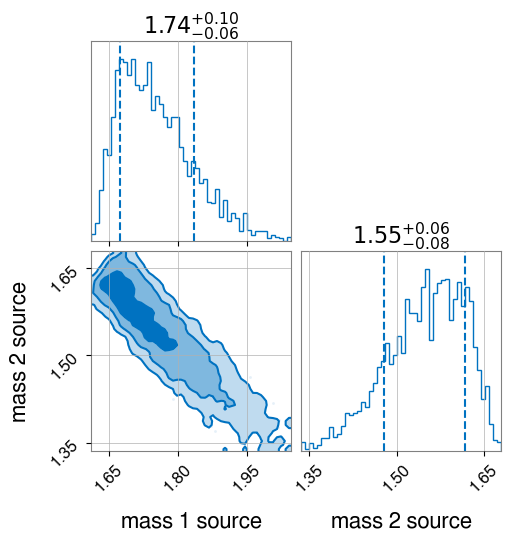

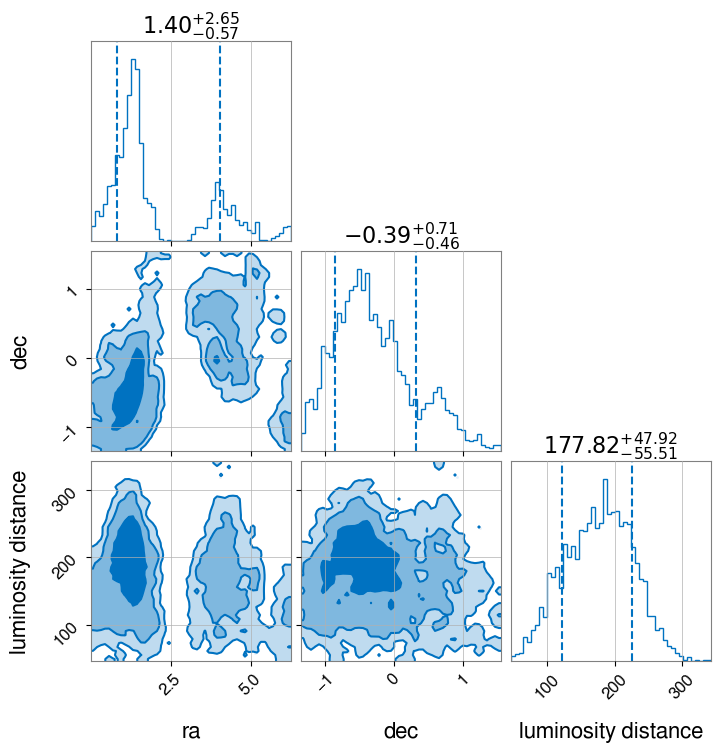

In [21]:
_ = result.plot_corner(save=False, parameters=["mass_1_source", "mass_2_source"])
plt.show()
plt.close()


_ = result.plot_corner(save=False, parameters=["ra", "dec", "luminosity_distance"])
plt.show()
plt.close()